In [1]:
#Introduction

In [2]:
#Part A: Cubic Spline Interpolation


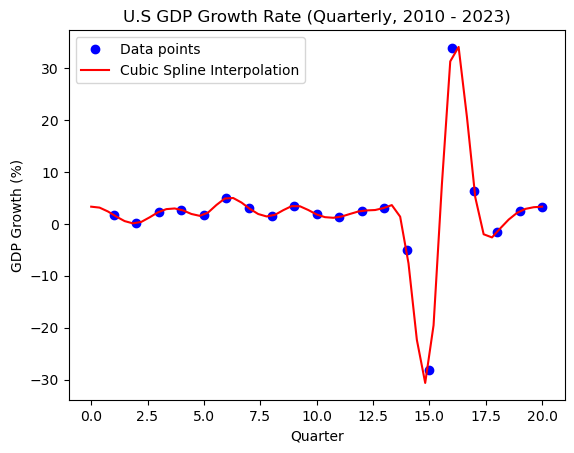

In [3]:
#PART A TESTING
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Define known data points
Quarter = np.arange(1, 21)
gdpGrowth = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# Create a cubic spline interpolation of the data
cs = CubicSpline(Quarter, gdpGrowth, bc_type='natural')

# Generate new x values for a smooth plot
x_interp = np.linspace(0, 20, 55)

#CHANGE THIS FOR QUESTION 1 AND 2 ^^^^^^^^^^




y_interp = cs(x_interp)

# Plot the original data and cubic spline interpolation
plt.plot(Quarter, gdpGrowth, 'bo', label="Data points")
plt.plot(x_interp, y_interp, 'r-', label="Cubic Spline Interpolation")
plt.title("U.S GDP Growth Rate (Quarterly, 2010 - 2023)")
plt.xlabel("Quarter")
plt.ylabel("GDP Growth (%)")
plt.legend()
plt.show()

In [4]:
#Part B: Polynomial & Least Squares Comparison

In [5]:
#PART B TESTING

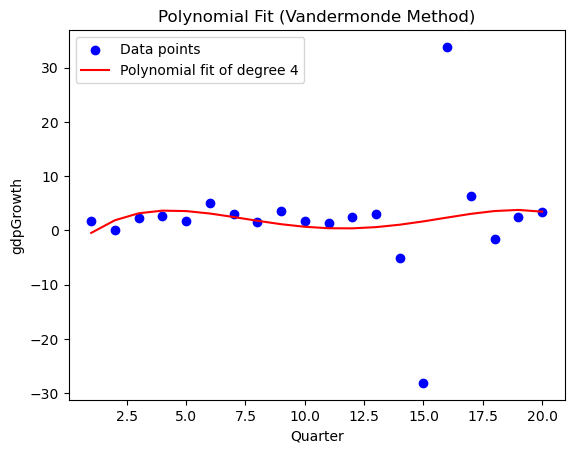

In [6]:
def create_vandermonde_matrix(x, degree):
    V = np.vander(x, N=degree+1, increasing=True)
    return V

degree = 4 # Degree of the polynomial

V = create_vandermonde_matrix(Quarter, degree)

# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, gdpGrowth)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)

#print("Polynomial Coefficients: ", coefficients)


polynomial = np.poly1d(coefficients[::-1])


# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(Quarter)
# Step 4: Plotting the results
plt.scatter(Quarter, gdpGrowth, color='blue', label='Data points') # Original data points
plt.plot(Quarter, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit (Vandermonde Method)')
plt.xlabel('Quarter')
plt.ylabel('gdpGrowth')
plt.legend()
plt.show()

Slope: 0.00014705882352951386, Intercept: 2.1424999999999996


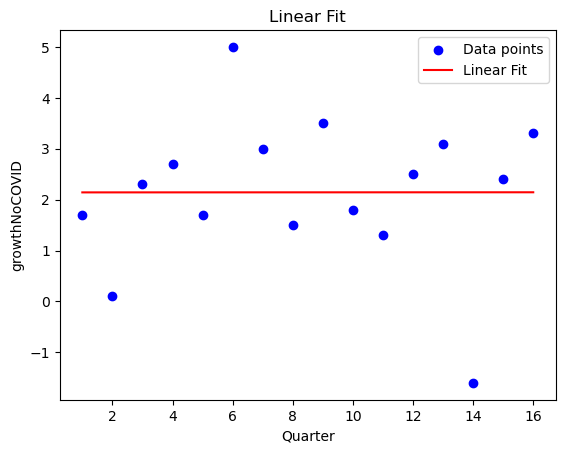

In [7]:
# Stack the design matrix with a column of ones (for the intercept)

Quarter = np.arange(1, 17)
growthNoCOVID = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3])

A = np.vstack([Quarter, np.ones(len(Quarter))]).T
# Solve using least squares
m, c = np.linalg.lstsq(A, growthNoCOVID, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

plt.scatter(Quarter, growthNoCOVID, color='blue', label='Data points') # Original data points
plt.plot(Quarter, (m*Quarter + c), color='red', label='Linear Fit')
plt.title('Linear Fit')
plt.xlabel('Quarter')
plt.ylabel('growthNoCOVID')
plt.legend()
plt.show()

In [8]:
#Part C: Method Justification

In [9]:
#PART C TESTING

In [11]:
# Mean Squared Error (MSE)
mse = np.mean((gdpGrowth - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')
# R-squared value
ss_total = np.sum((gdpGrowth - np.mean(gdpGrowth))**2)
ss_res = np.sum((gdpGrowth - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

Mean Squared Error: 99.3077
R-squared: 0.0166


In [ ]:
#Part C Addendum: Big O Analysis

In [ ]:
#PART C ADDENDUM TESTING

In [ ]:
#Conclusion